/Users/46668993/.pyenv/versions/qer_env/lib/python3.14/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


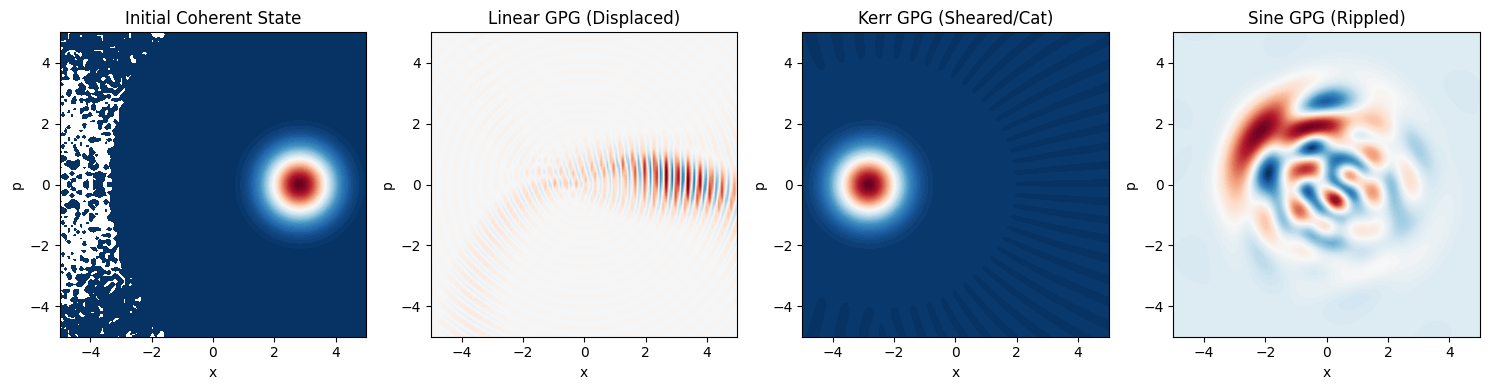

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

#parameters
N = 50 # number of spin-1/2s
alpha = 2.0 # coherent state parameter
T = 2*np.pi # total time for one period

# operators
a = destroy(N) #annihilation operator
n = a.dag() * a #number operator
x = (a + a.dag()) / np.sqrt(2) #position operator
p = 1j* (a.dag() - a) / np.sqrt(2) #momentum operator

#initial state: coherent state |alpha> 
psi0 = coherent(N, alpha)
#1. Hamiltonian (linear GPG): H = epsilon* (a.dag() e^{-i*delta*t} + hc) 
epsilon = 1.0
#delta = 1.0 
H_lin = epsilon * (a + a.dag())
#Evolve 
tlist = np.linspace(0, T, 200)
result_lin = mesolve(H_lin, psi0, tlist, [], []) 

#2. Hamiltonnian (nonlinear GPG): H = chi * (a.dag*a)^2
chi = 0.5
H_kerr = chi * n * n 
#Evolve
result_kerr = mesolve(H_kerr, psi0, tlist, [], [])

#3. Hamiltonian (non-linear) H = Omega*sin(theta*n + beta)
omega = 5.0
theta = 0.5
beta = 0.0 
sin_n = (theta*n + beta).sinm()
H_sin = omega * sin_n
#Evolve
result_sine = mesolve(H_sin, psi0, tlist, [], [])

#visualization
def plot_wigner(rho, title): 
    xvec = np.linspace(-5, 5, 100)
    W = wigner(rho, xvec, xvec)
    plt.contourf(xvec, xvec, W, 100, cmap='RdBu_r')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('p')

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

#plt the initial state
plt.sca(axes[0])
plot_wigner(psi0, "Initial Coherent State")

# Plot Final States
plt.sca(axes[1])
plot_wigner(result_lin.states[-1], "Linear GPG (Displaced)")
# Note: It stays a circle, just moves location.

plt.sca(axes[2])
plot_wigner(result_kerr.states[-1], "Kerr GPG (Sheared/Cat)")
# Note: The circle smears into a crescent.

plt.sca(axes[3])
plot_wigner(result_sine.states[-1], "Sine GPG (Rippled)")
# Note: Complex non-linear distortion.

plt.tight_layout()
plt.show()


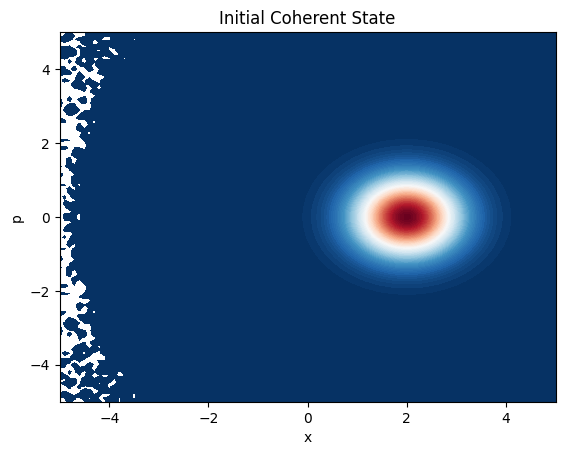

In [27]:
psi0 = coherent(N=50, alpha=np.sqrt(2))
plot_wigner(psi0, "Initial Coherent State")